In [1]:
ROOT = '../../..' # Relative position of the root folder.

In [2]:
import sys
sys.path.append(ROOT)

In [3]:
from libs import ConfigLoader

cfg_loader = ConfigLoader(f'{ROOT}/configs/cfg.yaml')
cfgs = cfg_loader.get_configs()
cfgs['use_dataset'] = 'roboflow-asl-dataset-1'
print(cfgs)

{'using_kaggle': False, 'input_folder': 'kaggle/input', 'use_dataset': 'roboflow-asl-dataset-1', 'kaggle_override': {'input_folder': 'kaggle/input'}, 'data': {'asl-dataset': {'path': 'synthetic-asl-alphabet', 'train': 'Train_Alphabet', 'test': 'Test_Alphabet'}, 'roboflow-asl-dataset-1': {'path': 'roboflow-asl-alphabet-1', 'train': 'train', 'test': 'test'}}, 'output': {'path': 'models/output'}}


In [4]:
from libs import ASLDataLoader

data_loader = ASLDataLoader(cfgs)
data_loader.check()

using_kaggle: False
use_dataset: roboflow-asl-dataset-1
input_folder: d:\kht3327\_Projects\Major FYP\proj\kaggle\input\roboflow-asl-alphabet-1
train_data_path: d:\kht3327\_Projects\Major FYP\proj\kaggle\input\roboflow-asl-alphabet-1\train
test_data_path: d:\kht3327\_Projects\Major FYP\proj\kaggle\input\roboflow-asl-alphabet-1\test
dataset: None
dataloader: None


In [5]:
data_loader.display_data_info(train=True)

Number of images: 23753
Number of unique classes: 99


In [6]:
data_loader.display_data_info(train=False)

Number of images: 997
Number of unique classes: 90


In [7]:
from torchvision import transforms

In [8]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

In [9]:
train_dataset = data_loader.get_dataset(train=True, transform=transform)

In [10]:
import os
import random
from libs import visualize_sample_images, visualize_dataset_images, visualize_dataloader_images

Samples from train


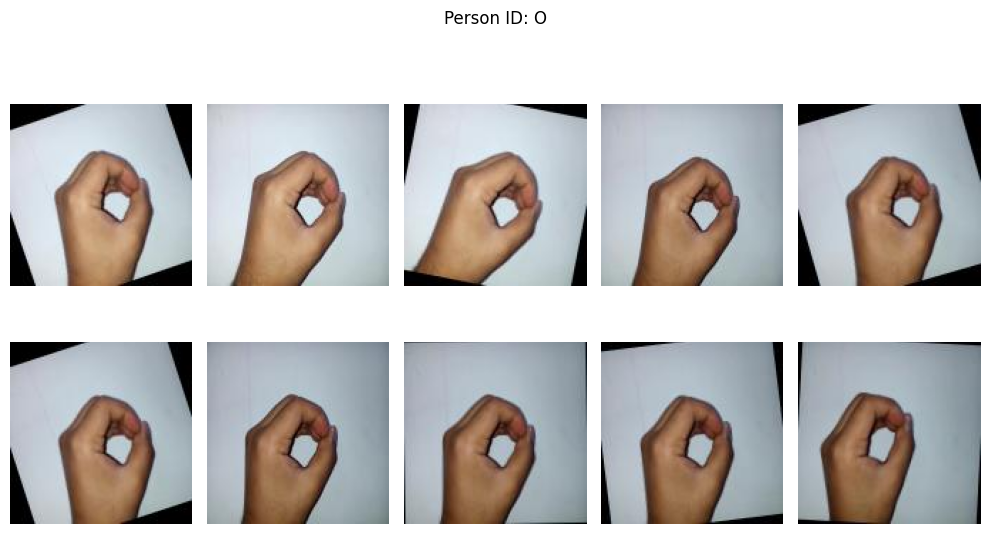

In [11]:
class_id = random.choice(os.listdir(data_loader.train_data_path))
folder_path = os.path.join(data_loader.train_data_path, class_id)
print(f'Samples from {os.path.basename(data_loader.train_data_path)}')
visualize_sample_images(folder_path)

In [12]:
import torchvision.transforms as transforms

desired_height, desired_width = 512, 512
data_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(degrees=10),  # Rotation range
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Width and height shift
    transforms.RandomHorizontalFlip(),  # Horizontal flip
    transforms.RandomResizedCrop(size=(desired_height, desired_width), scale=(0.8, 1.0)),  # Zoom
    
    # transforms.Resize((desired_height, desired_width)),  # Ensure consistent size
])

In [13]:
train_loader = data_loader.get_dataloader(train=True, mode='standard', transform=data_transforms)

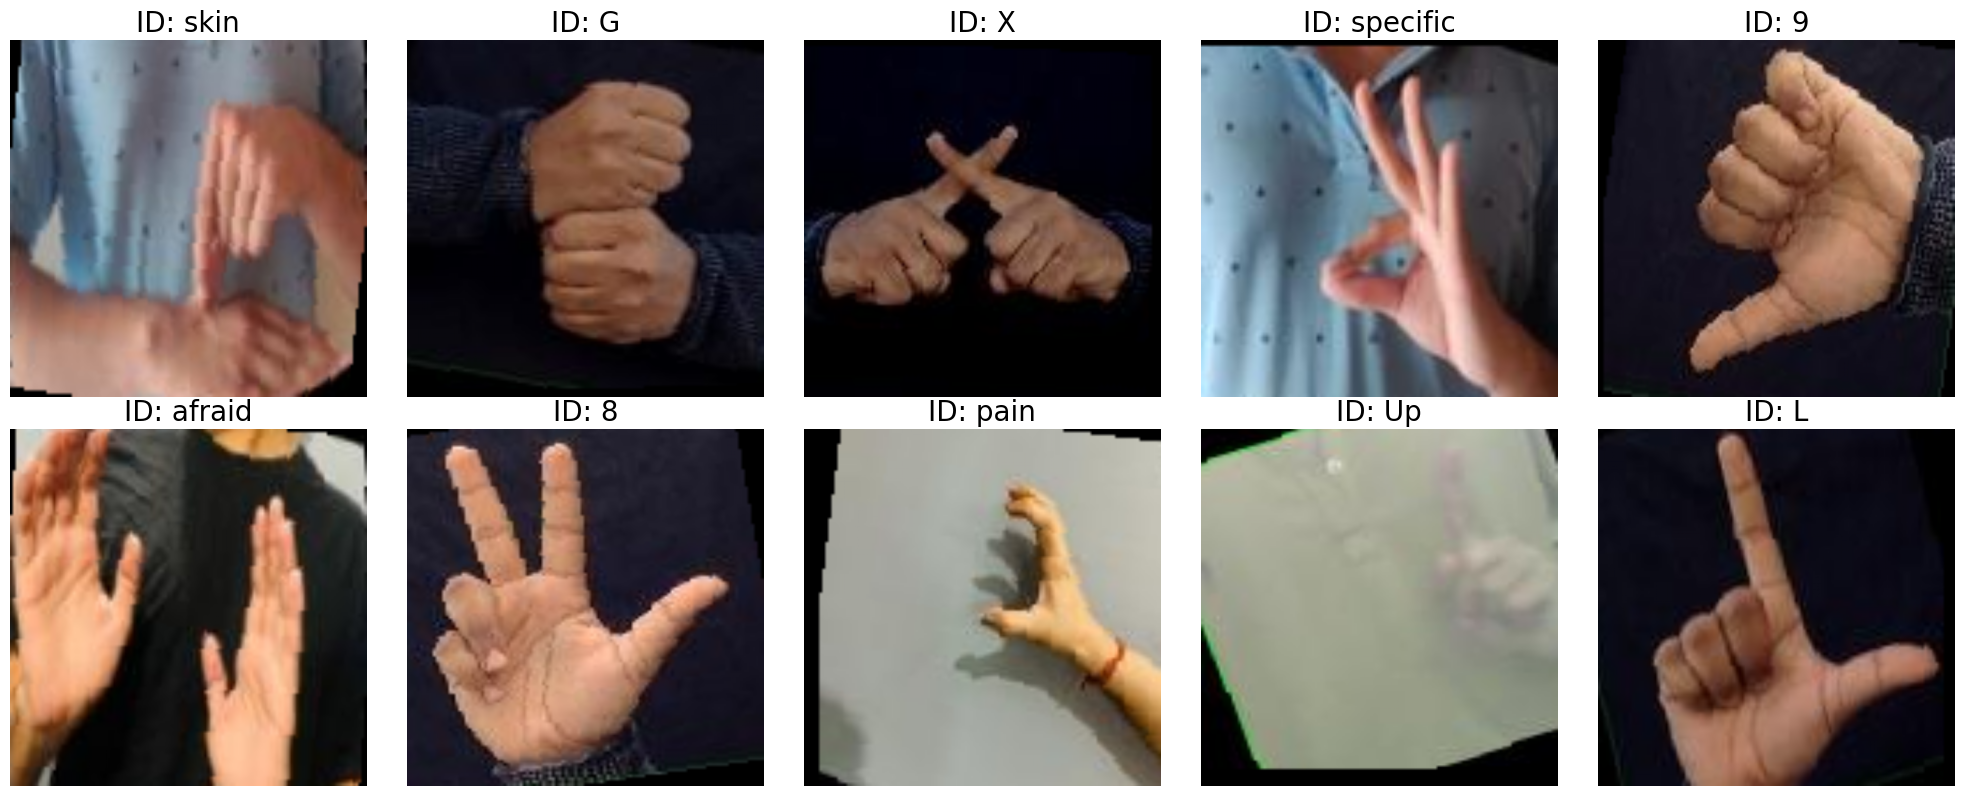

In [14]:
visualize_dataloader_images(train_loader)

In [15]:
from libs.models.efficientnet_mlp_classifier import SimpleClassifier

In [16]:
NUM_CLASSES = len(train_dataset.classes)

In [17]:
model = SimpleClassifier(num_classes=NUM_CLASSES)

Loaded pretrained weights for efficientnet-b7
Num layers: 9


In [18]:
print(model)

SimpleClassifier(
  (model): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePa

In [19]:
from libs.trainers.trainer_ce import train_one_epoch, test_one_epoch
import torch.nn as nn
from torchvision import transforms
from torch.optim import Adam

In [20]:
test_loader = data_loader.get_dataloader(train=False, mode='standard')

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

In [22]:
num_epochs = 30
device = 'cuda'

In [23]:
from libs.model_loader import save_model, load_model

In [24]:
# Load the model
loaded_model = SimpleClassifier(num_classes=27)
loaded_model = load_model(loaded_model, f'{ROOT}/saved_models/model-2024-10-28-1.pth')

Loaded pretrained weights for efficientnet-b7
Num layers: 9


d:\kht3327\_Projects\Major FYP\proj\tests\3_modularization_test\../..\libs\model_loader.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load

Model loaded from ../../saved_models/model-2024-10-28-1.pth


In [25]:
loaded_model.to(device)
# test_one_epoch(loaded_model, test_loader, criterion, device=device)

SimpleClassifier(
  (model): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePa

In [26]:
from libs.verifiers.verifier import extract_features, plot_tsne

In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [28]:
features, labels = extract_features(loaded_model, test_loader)

100%|██████████| 32/32 [00:03<00:00,  8.18it/s]


In [29]:
classes = train_dataset.unique_labels
labels_id = [classes[label] for label in labels]

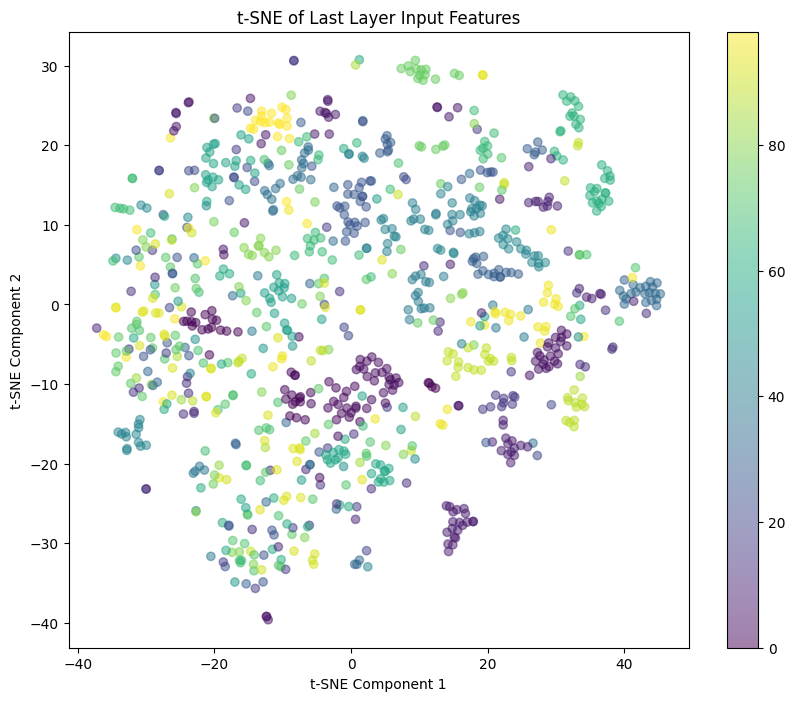

In [30]:
plot_tsne(features, labels_id)

In [31]:
from libs.verifiers.verifier import plot_similarity_matrix

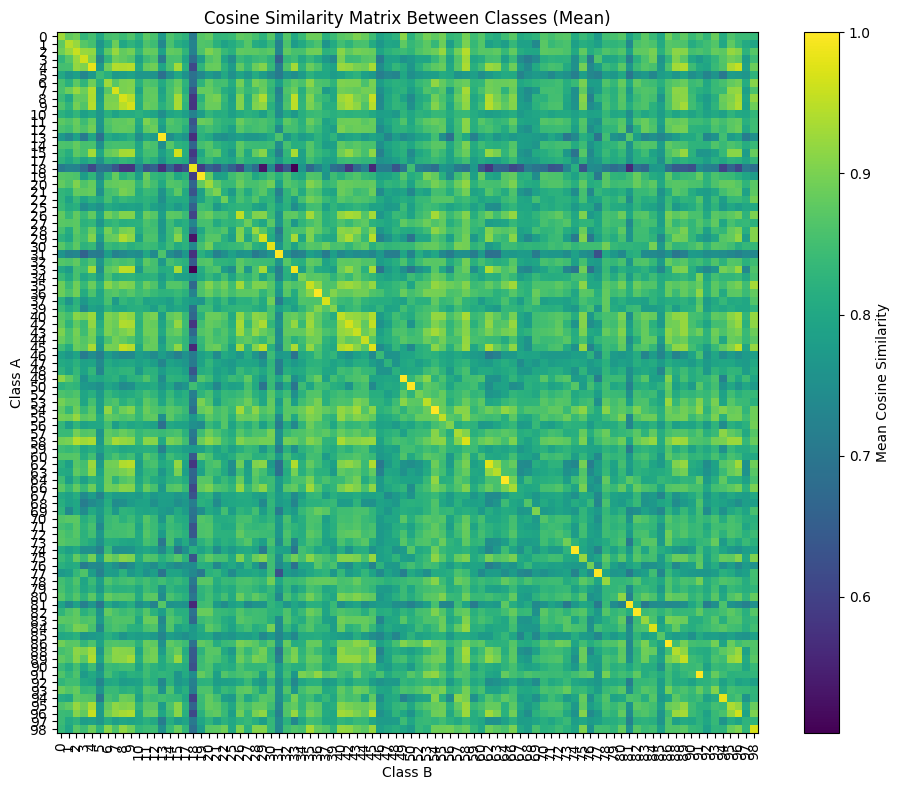

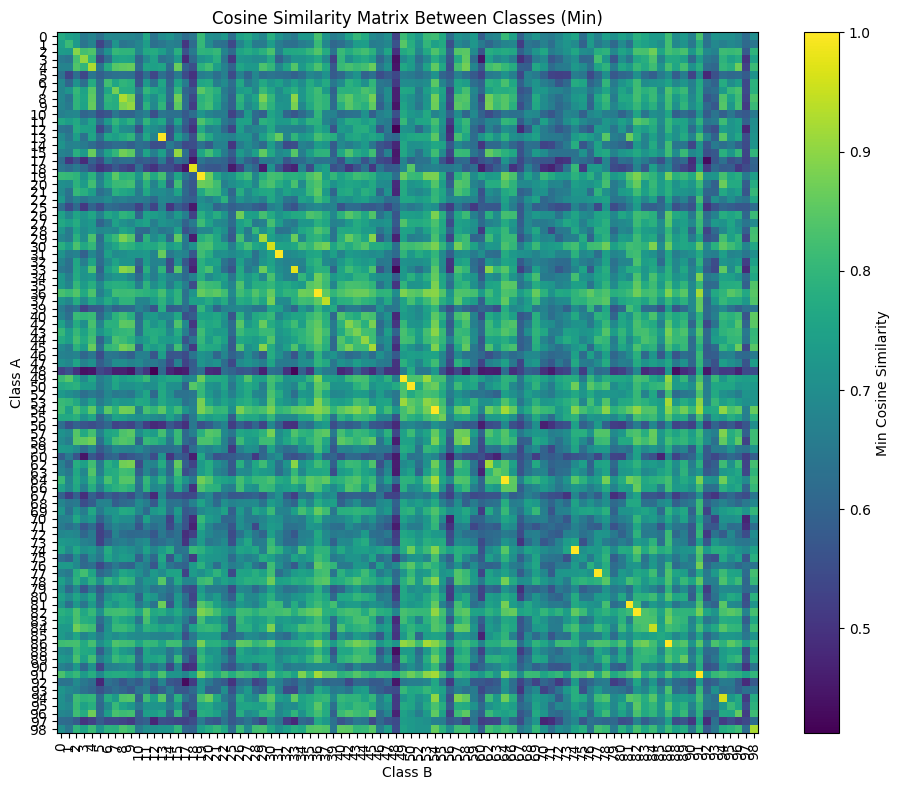

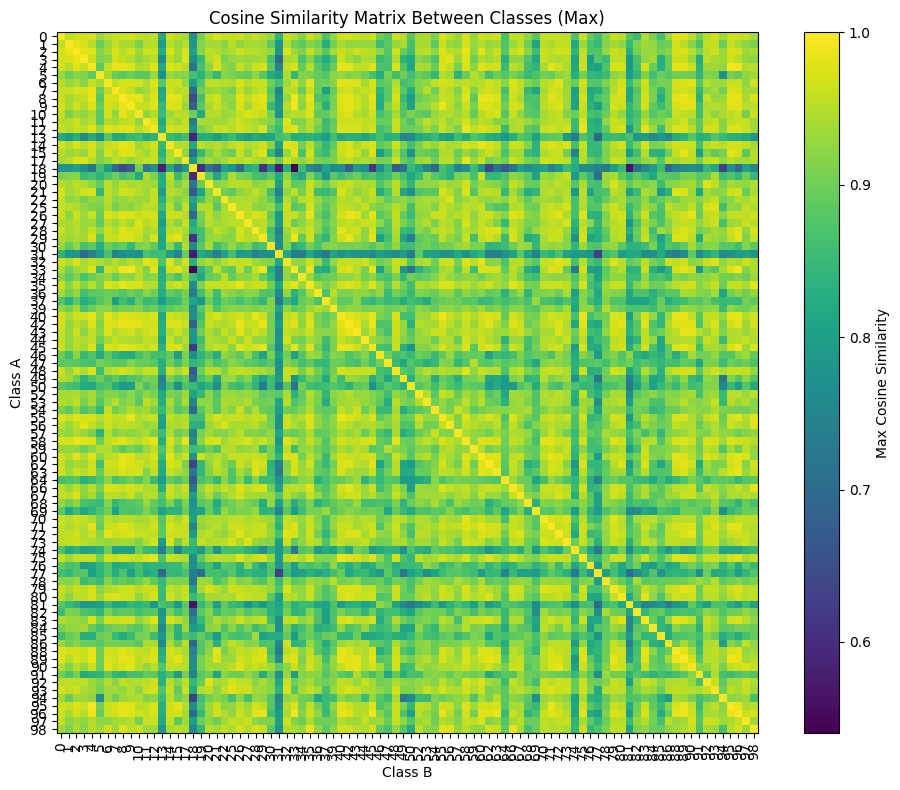

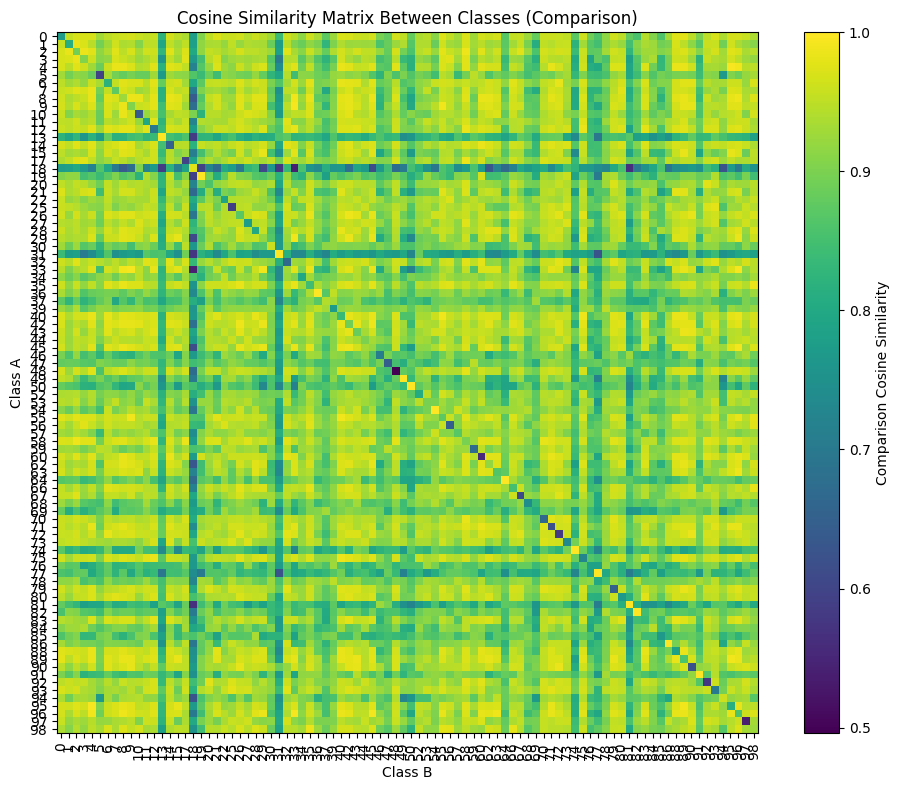

In [32]:
sim_mats = plot_similarity_matrix(features, labels_id)

In [35]:
np.argmax(sim_mats[0], axis=0), np.argmax(sim_mats[0], axis=1)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 33, 52, 52, 13, 52, 15, 32,
        17, 18, 19, 20, 32, 33, 23, 47, 25, 26, 27, 28, 52, 30, 82, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 82, 48, 48, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 78, 52, 55, 56, 57, 58, 48, 60, 61, 52, 52, 78, 65, 66, 67,
        68, 69, 70, 78, 72, 73, 74, 75, 76, 77, 78, 79, 80, 48, 82, 52, 84,
        85, 86, 87, 78, 89], dtype=int64),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 33, 52, 52, 13, 52, 15, 32,
        17, 18, 19, 20, 32, 33, 23, 47, 25, 26, 27, 28, 52, 30, 82, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 82, 48, 48, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 78, 52, 55, 56, 57, 58, 48, 60, 61, 52, 52, 78, 65, 66, 67,
        68, 69, 70, 78, 72, 73, 74, 75, 76, 77, 78, 79, 80, 48, 82, 52, 84,
        85, 86, 87, 78, 89], dtype=int64))